In [4]:
##### Creates maps of agricultural capital stock and labor (rasters)

import os
import pandas as pd
import geopandas as gpd
import rioxarray as rio
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from glob import glob
import rasterio
from rasterio.warp import reproject, Resampling
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
from pyproj import Transformer

In [5]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# Import data
capital = rio.open_rasterio(f"{cd}/Results/Raster_model/rescaled_capital_USD.tif")
capital_p10 = rio.open_rasterio(f"{cd}/Results/Raster_model/rescaled_capital_USD_p10.tif")
capital_p90 = rio.open_rasterio(f"{cd}/Results/Raster_model/rescaled_capital_USD_p90.tif")

labor = rio.open_rasterio(f"{cd}/Results/Raster_model/rescaled_jobs.tif")
labor_p10 = rio.open_rasterio(f"{cd}/Results/Raster_model/rescaled_jobs_p10.tif")
labor_p90 = rio.open_rasterio(f"{cd}/Results/Raster_model/rescaled_jobs_p90.tif")

production = rio.open_rasterio(f'{cd}/Data/Clean/Production/total_production_tonnes_2020.tif')

country_boundaries = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/gadm_410-levels.gpkg", layer='ADM_0')

# National data
capital_national = pd.read_csv(f'{cd}/Data/Clean/Capital_stock/FAO_capital_stock_adjusted.csv')
labor_national = pd.read_csv(f'{cd}/Data/Clean/Labor/ILO_ag_labor_estimate_adjusted.csv')
country_codes = pd.read_csv(f"{cd}/Data/Correspondence_tables/country_names.csv", encoding="cp1252")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/map_capital_labor_raster"

In [6]:
### Data prep

# align crs

crs = "ESRI:54042"

capital = capital.rio.reproject(crs)
capital_p10 = capital_p10.rio.reproject(crs)
capital_p90 = capital_p90.rio.reproject(crs)

labor = labor.rio.reproject(crs)
labor_p10 = labor_p10.rio.reproject(crs)
labor_p90 = labor_p90.rio.reproject(crs)

production = production.rio.reproject(crs)

country_boundaries = country_boundaries.to_crs(crs)

# convert units 
capital_million = capital / 1e6
capital_million_p10 = capital_p10 / 1e6
capital_million_p90 = capital_p90 / 1e6

# calculate % differnce 
capital_p10_percent_diff = (capital_million_p10 - capital_million) / capital_million
capital_p90_percent_diff = (capital_million_p90 - capital_million) / capital_million

labor_p10_percent_diff = (labor_p10 - labor) / labor
labor_p90_percent_diff = (labor_p90 - labor) / labor

In [7]:
##### Calculate intensity rasters 

# calculate intensities
production_masked = production.where(production >= 0.1) 
capital_intensity_USD_per_tonne = capital / production_masked
labor_intensity_thousand_jobs_per_tonne = (labor / production_masked) * 1e3

capital_intensity_USD_per_tonne = capital_intensity_USD_per_tonne.where(
    np.isfinite(capital_intensity_USD_per_tonne)
)
labor_intensity_thousand_jobs_per_tonne = labor_intensity_thousand_jobs_per_tonne.where(
    np.isfinite(labor_intensity_thousand_jobs_per_tonne)
)

# Set nodata value  
capital_intensity_USD_per_tonne = capital_intensity_USD_per_tonne.rio.write_nodata(np.nan)
labor_intensity_thousand_jobs_per_tonne = labor_intensity_thousand_jobs_per_tonne.rio.write_nodata(np.nan)

# Set CRS 
capital_intensity_USD_per_tonne = capital_intensity_USD_per_tonne.rio.write_crs(crs)
labor_intensity_thousand_jobs_per_tonne = labor_intensity_thousand_jobs_per_tonne.rio.write_crs(crs)

# Save
capital_intensity_USD_per_tonne.rio.to_raster(
    f"{cd}/Results/Raster_model/capital_intensity_USD_per_tonne.tif",
    dtype="float32",
    compress="LZW"
)

labor_intensity_thousand_jobs_per_tonne.rio.to_raster(
    f"{cd}/Results/Raster_model/labor_intensity_thousand_jobs_per_tonne.tif",
    dtype="float32",
    compress="LZW"
)

In [8]:
##### Identify no data countries 

country_data = country_codes.merge(capital_national, on='ISO3', how='left')
country_data = country_data.merge(labor_national, on='ISO3', how='left')

country_data['has_capital_data'] = (country_data['ag_capital_stock_mil_USD_nominal'].notna().astype(int))
country_data['has_labor_data'] = (country_data['ag_labor_thousands_2020'].notna().astype(int))

col_to_keep = ['SHP_code', 'has_capital_data', 'has_labor_data']

country_data = country_data[col_to_keep]

country_boundaries = country_boundaries.merge(country_data, left_on='GID_0', right_on='SHP_code', how='left')
country_boundaries['has_capital_data'] = country_boundaries['has_capital_data'].fillna(0)
country_boundaries['has_labor_data'] = country_boundaries['has_labor_data'].fillna(0)

In [9]:
values = capital_intensity_USD_per_tonne.values.flatten()

# drop NaNs (rasters typically have nodata pixels, e.g. ocean/non-agricultural areas)
values_clean = values[~np.isnan(values)]

# further restrict to values strictly above 0
values_clean = values_clean[values_clean > 0]

print(f"Total pixels: {len(values)}")
print(f"Valid (non-NaN, >0) pixels: {len(values_clean)}")

# pull every 10th percentile: 10, 20, 30, ..., 100
percentiles = np.arange(10, 101, 10)
percentile_values = np.percentile(values_clean, percentiles)

for p, v in zip(percentiles, percentile_values):
    print(f"{p}th percentile: {v:.2f}")

Total pixels: 27159875
Valid (non-NaN, >0) pixels: 5215090
10th percentile: 152.19
20th percentile: 283.94
30th percentile: 409.59
40th percentile: 570.50
50th percentile: 800.58
60th percentile: 1097.35
70th percentile: 1425.81
80th percentile: 1956.49
90th percentile: 2811.02
100th percentile: 357306.56


#### Map capital

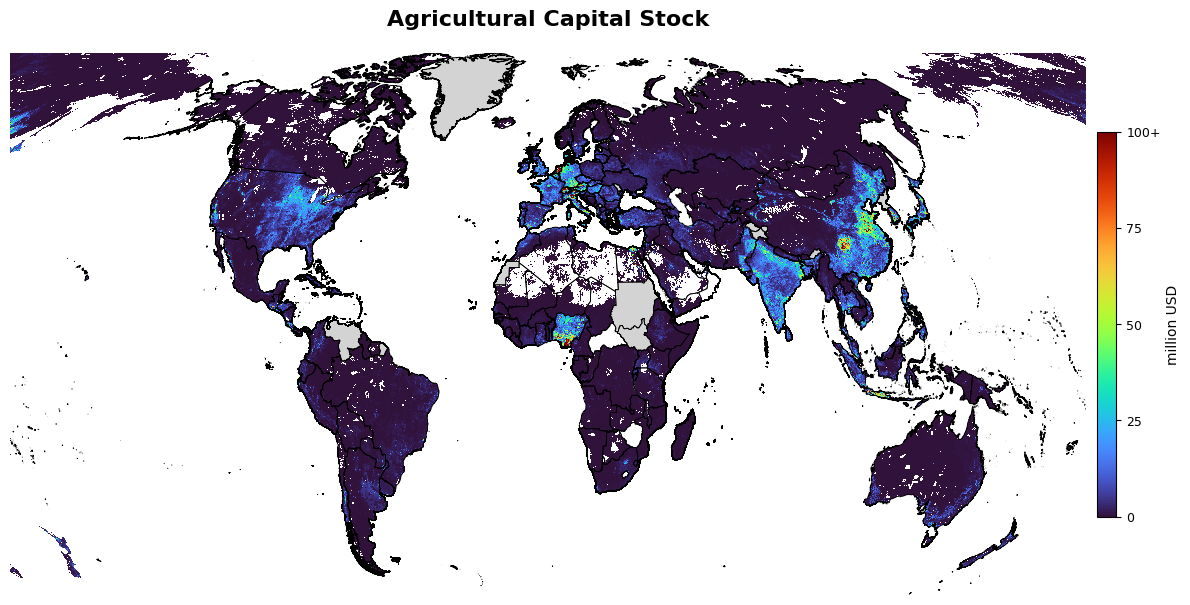

In [10]:
##### Produce global map of capital (mean estimate) 

# Prepare raster
value_plot = capital_million.squeeze()
name = 'capital_stock'

bounds = [0, 25, 50, 75, 100] 
labels = ['0', '25', '50', '75', '100+']

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Countries with no data (light grey fill)
country_boundaries[country_boundaries["has_capital_data"] == 0].plot(
    ax=ax,
    facecolor="lightgrey",   
    edgecolor="none",
    zorder=0
)

# Country borders 
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=2
)

# Raster
im = value_plot.plot(
    ax=ax,
    cmap="turbo",
    vmin=0,
    vmax=100,
    add_colorbar=False,
    add_labels=False,
    zorder=1
)

# Clip to country_boundaries
minx, miny, maxx, maxy = country_boundaries.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_axis_off()
ax.set_title("Agricultural Capital Stock", fontsize=16, weight='bold', pad=20)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.02,
    pad=0.01, 
    shrink=0.5
)
cbar.set_label("million USD", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Set ticks and labels
cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/{name}.png", dpi=300, bbox_inches='tight')

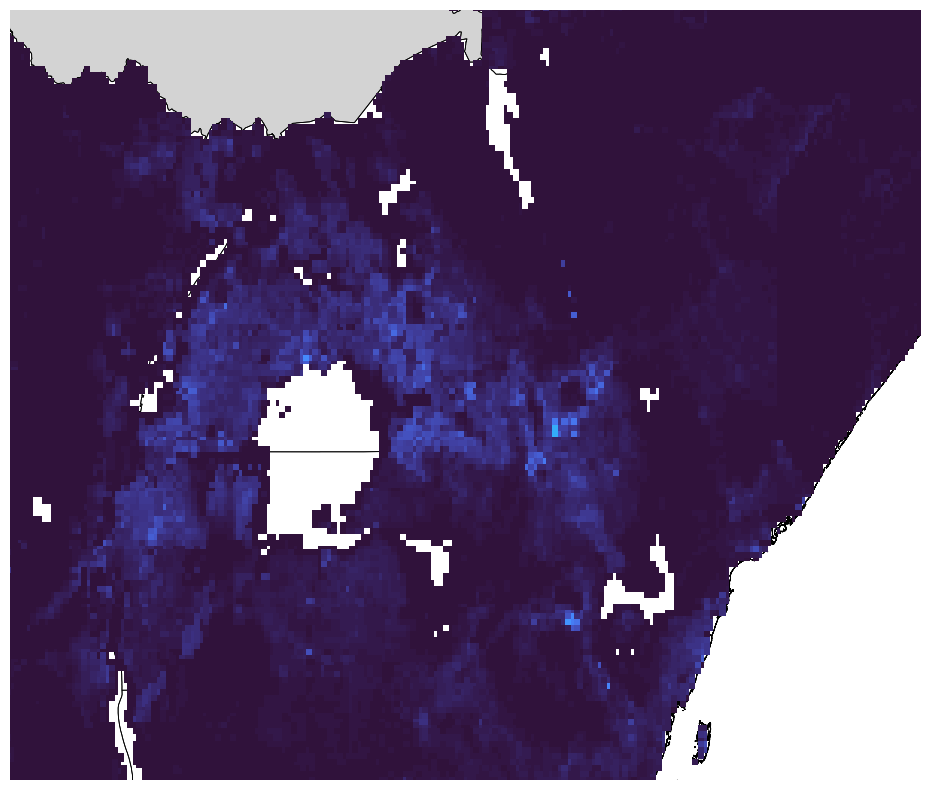

In [11]:
##### Produce regional map of capital stock 

# Prepare raster
value_plot = capital_million.squeeze()

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Countries with no data (light grey fill)
country_boundaries[country_boundaries["has_capital_data"] == 0].plot(
    ax=ax,
    facecolor="lightgrey",   
    edgecolor="none",
    zorder=0
)

# Country borders underneath
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=2
)

# Raster on top
im = value_plot.plot(
    ax=ax,
    cmap="turbo",
    vmin=0,
    vmax=100,
    add_colorbar=False,
    add_labels=False,
    zorder=2
)

transformer = Transformer.from_crs("EPSG:4326", "ESRI:54042", always_xy=True)

# Set bbox for region of interest 

# # Europe
# minx, miny = transformer.transform(-15.108776, 41.834654)
# maxx, maxy = transformer.transform(31.868763, 59.016438)

# # Egypt & the Levant 
# minx, miny = transformer.transform(23.819561, 21.459939)
# maxx, maxy = transformer.transform(40.167217, 36.037301)

# # Colombia & Venezuela
# minx, miny = transformer.transform(-80.024414,-2.108899)
# maxx, maxy = transformer.transform(-59.677734,13.923404)

# # China and East Asia 
# minx, miny = transformer.transform(98.026886,20.106878)
# maxx, maxy = transformer.transform(150.409698,46.049884)

# East Africa
minx, miny = transformer.transform(27.421875,-5.747174)
maxx, maxy = transformer.transform(43.637695,5.353521)

# # West Africa
# minx, miny = transformer.transform(-7.638554,-0.63891)
# maxx, maxy = transformer.transform(20.229231,19.330259)

# # Continental US
# minx, miny = transformer.transform(-130.609589,20.777383)
# maxx, maxy = transformer.transform(-66.976776,49.675182)

# Rest
ax.set_xlim([minx, maxx])
ax.set_ylim([miny, maxy])   

ax.set_axis_off()

plt.tight_layout()
plt.show()

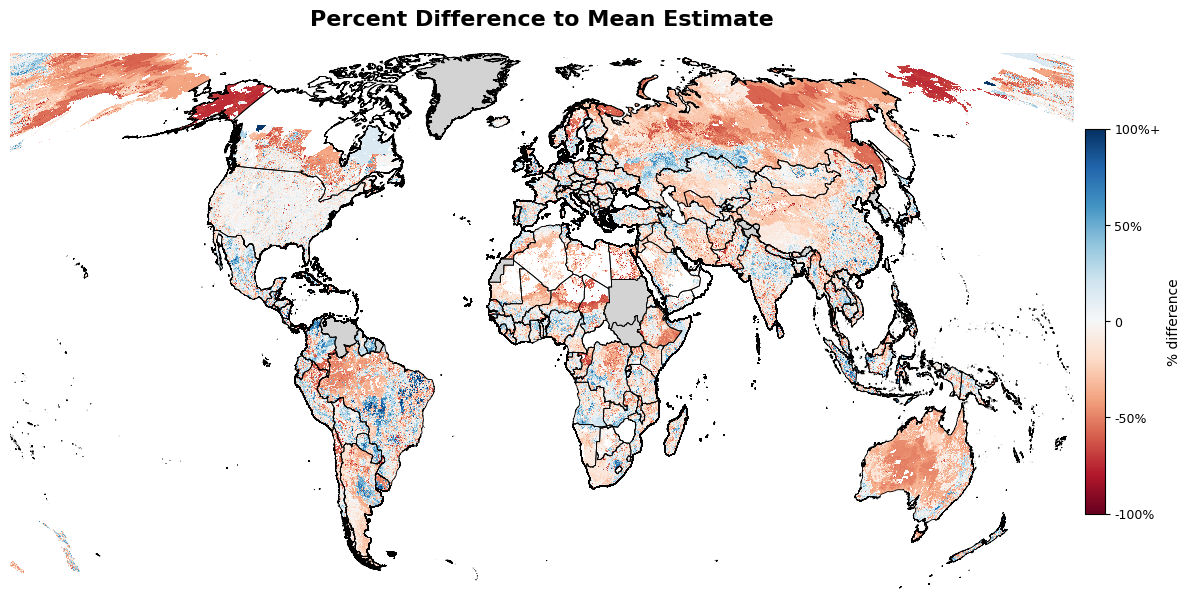

In [12]:
##### Global map of sensitivity of capital estimates (mean vs p10/p90)

# Prepare raster
value_plot = capital_p10_percent_diff.squeeze()
name = 'capital_stock_p10_comparison'

bounds = [-1, -0.5, 0, 0.5, 1] 
labels = ['-100%', '-50%', '0', '50%', '100%+']

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Countries with no data (light grey fill)
country_boundaries[country_boundaries["has_capital_data"] == 0].plot(
    ax=ax,
    facecolor="lightgrey",   
    edgecolor="none",
    zorder=0
)

# Country borders 
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=2
)

# Raster
im = value_plot.plot(
    ax=ax,
    cmap="RdBu",
    vmin=-1,
    vmax=1,
    add_colorbar=False,
    add_labels=False,
    zorder=1
)

# Clip to country_boundaries
minx, miny, maxx, maxy = country_boundaries.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_axis_off()
ax.set_title("Percent Difference to Mean Estimate", fontsize=16, weight='bold', pad=20)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.02,
    pad=0.01, 
    shrink=0.5
)
cbar.set_label("% difference", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Set ticks and labels
cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/{name}.png", dpi=300, bbox_inches='tight')

#### Map labor

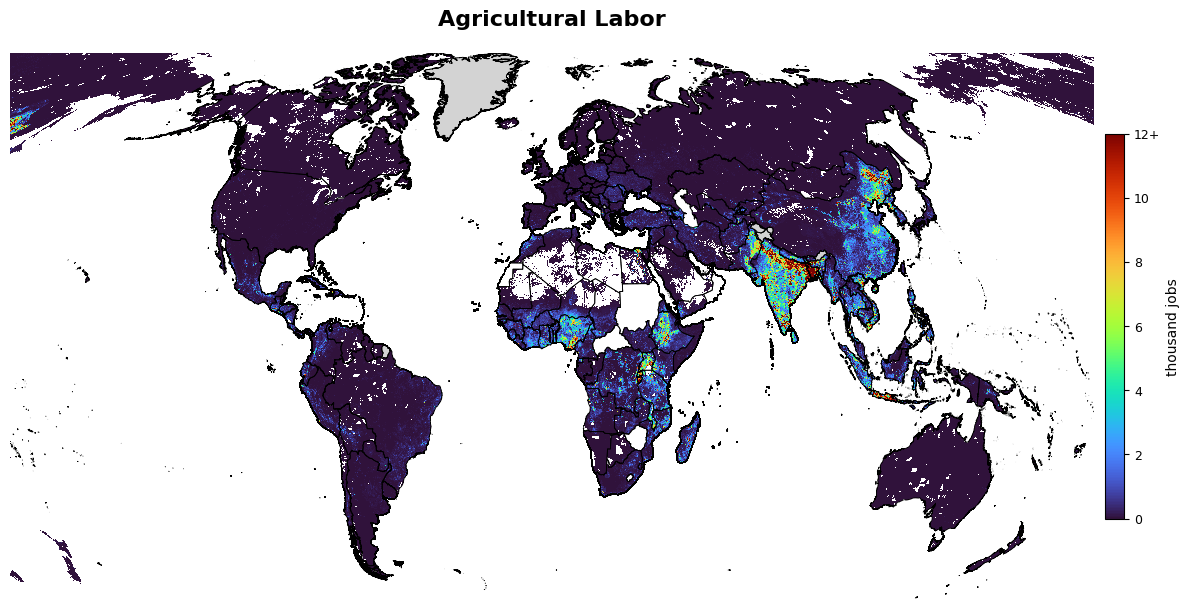

In [13]:
##### Produce global map of labor (mean estimate) 

# Prepare raster
value_plot = labor.squeeze()
name = 'labor'

bounds = [0, 2000, 4000, 6000, 8000, 10000, 12000] 
labels = ['0', '2', '4', '6', '8', '10', '12+']

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Countries with no data (light grey fill)
country_boundaries[country_boundaries["has_labor_data"] == 0].plot(
    ax=ax,
    facecolor="lightgrey",   
    edgecolor="none",
    zorder=0
)

# Country borders 
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=2
)

# Raster
im = value_plot.plot(
    ax=ax,
    cmap="turbo",
    vmin=0,
    vmax=12000,
    add_colorbar=False,
    add_labels=False,
    zorder=1
)

# Clip to country_boundaries
minx, miny, maxx, maxy = country_boundaries.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_axis_off()
ax.set_title("Agricultural Labor", fontsize=16, weight='bold', pad=20)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.02,
    pad=0.01, 
    shrink=0.5
)
cbar.set_label("thousand jobs", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Set ticks and labels
cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/{name}.png", dpi=300, bbox_inches='tight')

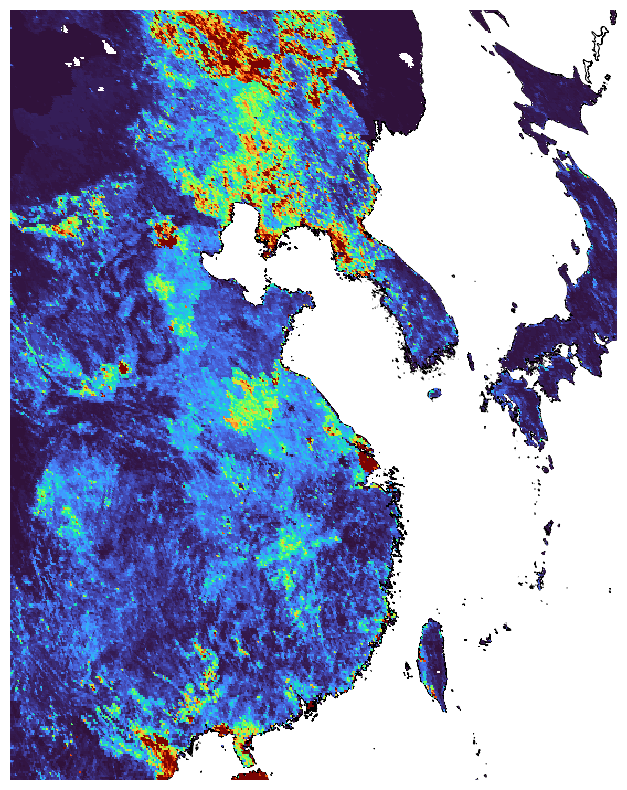

In [14]:
##### Produce regional map of labor 

# Prepare raster
value_plot = labor.squeeze()

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Countries with no data (light grey fill)
country_boundaries[country_boundaries["has_labor_data"] == 0].plot(
    ax=ax,
    facecolor="lightgrey",   
    edgecolor="none",
    zorder=0
)

# Country borders underneath
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=2
)

# Raster on top
im = value_plot.plot(
    ax=ax,
    cmap="turbo",
    vmin=0,
    vmax=12000,
    add_colorbar=False,
    add_labels=False,
    zorder=2
)

transformer = Transformer.from_crs("EPSG:4326", "ESRI:54042", always_xy=True)

# Set bbox for region of interest 

# # Europe
# minx, miny = transformer.transform(-15.108776, 41.834654)
# maxx, maxy = transformer.transform(31.868763, 59.016438)

# # Egypt & the Levant 
# minx, miny = transformer.transform(23.819561, 21.459939)
# maxx, maxy = transformer.transform(40.167217, 36.037301)

# # Colombia & Venezuela
# minx, miny = transformer.transform(-80.024414,-2.108899)
# maxx, maxy = transformer.transform(-59.677734,13.923404)

# China and East Asia 
minx, miny = transformer.transform(98.026886,20.106878)
maxx, maxy = transformer.transform(150.409698,46.049884)

# # East Africa
# minx, miny = transformer.transform(27.421875,-5.747174)
# maxx, maxy = transformer.transform(43.637695,5.353521)

# # West Africa
# minx, miny = transformer.transform(-7.638554,-0.63891)
# maxx, maxy = transformer.transform(20.229231,19.330259)

# # Continental US
# minx, miny = transformer.transform(-130.609589,20.777383)
# maxx, maxy = transformer.transform(-66.976776,49.675182)

# # South Asia
# minx, miny = transformer.transform(64.100408,4.781048)
# maxx, maxy = transformer.transform(115.088784,33.391893)

# Rest
ax.set_xlim([minx, maxx])
ax.set_ylim([miny, maxy])   

ax.set_axis_off()

plt.tight_layout()
plt.show()

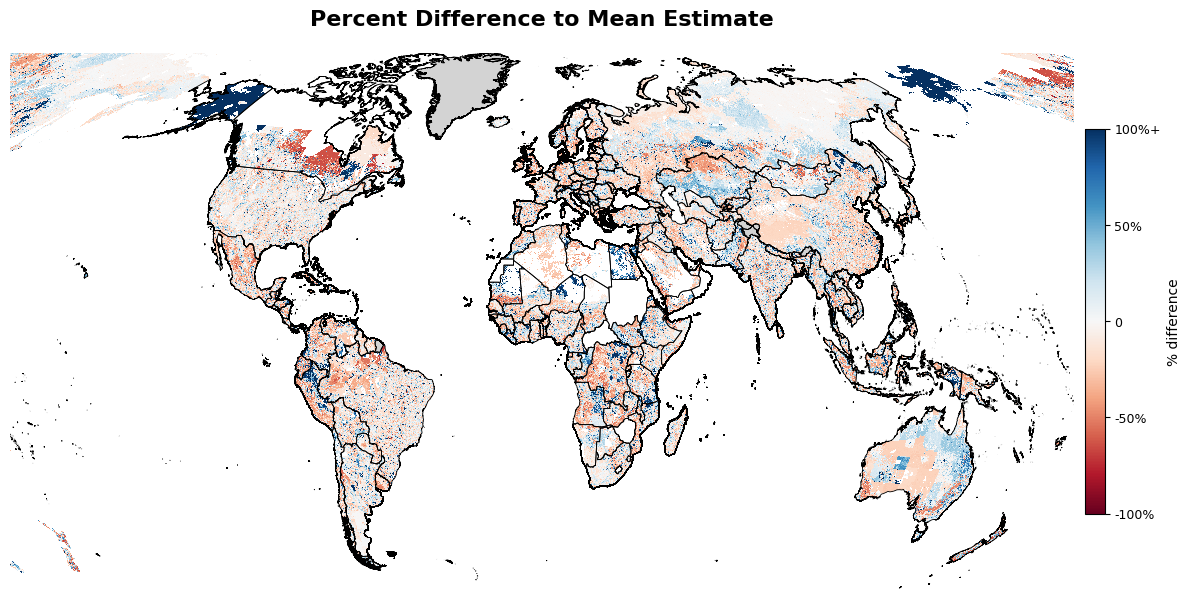

In [15]:
##### Global map of sensitivity of labor estimates (mean vs p10/p90)

# Prepare raster
value_plot = labor_p90_percent_diff.squeeze()
name = 'labor_p90_comparison'

bounds = [-1, -0.5, 0, 0.5, 1] 
labels = ['-100%', '-50%', '0', '50%', '100%+']

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Countries with no data (light grey fill)
country_boundaries[country_boundaries["has_labor_data"] == 0].plot(
    ax=ax,
    facecolor="lightgrey",   
    edgecolor="none",
    zorder=0
)

# Country borders 
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=2
)

# Raster
im = value_plot.plot(
    ax=ax,
    cmap="RdBu",
    vmin=-1,
    vmax=1,
    add_colorbar=False,
    add_labels=False,
    zorder=1
)

# Clip to country_boundaries
minx, miny, maxx, maxy = country_boundaries.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_axis_off()
ax.set_title("Percent Difference to Mean Estimate", fontsize=16, weight='bold', pad=20)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.02,
    pad=0.01, 
    shrink=0.5
)
cbar.set_label("% difference", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Set ticks and labels
cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/{name}.png", dpi=300, bbox_inches='tight')

#### Map intensities

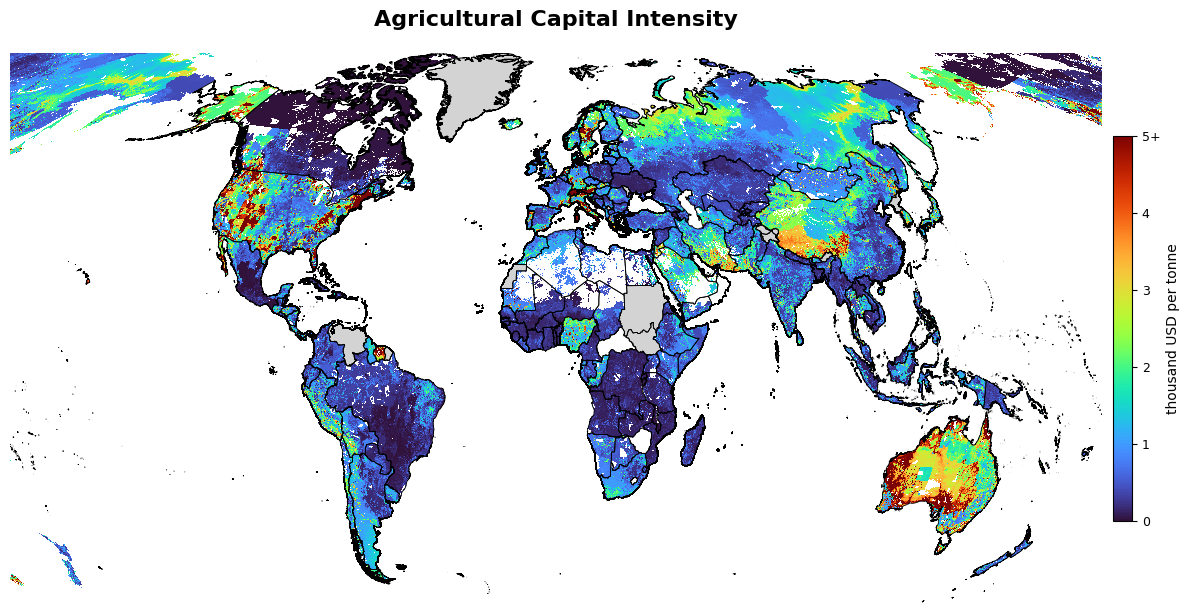

In [16]:
##### Produce global map of capital intensity

# Prepare raster
value_plot = capital_intensity_USD_per_tonne.squeeze()
name = 'capital_intensity'

bounds = [0, 1000, 2000, 3000, 4000, 5000] 
labels = ['0', '1', '2', '3', '4', '5+']

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Countries with no data (light grey fill)
country_boundaries[country_boundaries["has_capital_data"] == 0].plot(
    ax=ax,
    facecolor="lightgrey",   
    edgecolor="none",
    zorder=0
)

# Country borders 
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=2
)

# Raster
im = value_plot.plot(
    ax=ax,
    cmap="turbo",
    vmin=0,
    vmax=5000,
    add_colorbar=False,
    add_labels=False,
    zorder=1
)

# Clip to country_boundaries
minx, miny, maxx, maxy = country_boundaries.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_axis_off()
ax.set_title("Agricultural Capital Intensity", fontsize=16, weight='bold', pad=20)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.02,
    pad=0.01, 
    shrink=0.5
)
cbar.set_label("thousand USD per tonne", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Set ticks and labels
cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/{name}.png", dpi=300, bbox_inches='tight')

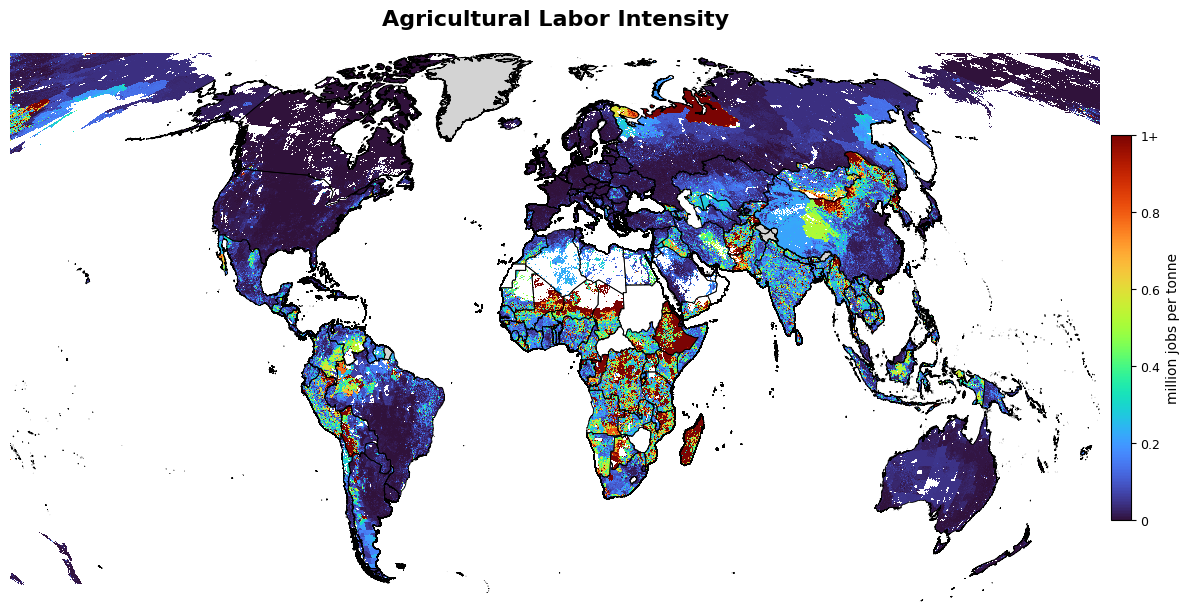

In [17]:
##### Produce global map of labor intensity

# Prepare raster
value_plot = labor_intensity_thousand_jobs_per_tonne.squeeze()
name = 'labor_intensity'

bounds = [0, 200, 400, 600, 800, 1000] 
labels = ['0', '0.2', '0.4', '0.6', '0.8', '1+']

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Countries with no data (light grey fill)
country_boundaries[country_boundaries["has_labor_data"] == 0].plot(
    ax=ax,
    facecolor="lightgrey",   
    edgecolor="none",
    zorder=0
)

# Country borders 
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=2
)

# Raster
im = value_plot.plot(
    ax=ax,
    cmap="turbo",
    vmin=0,
    vmax=1000,
    add_colorbar=False,
    add_labels=False,
    zorder=1
)

# Clip to country_boundaries
minx, miny, maxx, maxy = country_boundaries.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_axis_off()
ax.set_title("Agricultural Labor Intensity", fontsize=16, weight='bold', pad=20)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    fraction=0.02,
    pad=0.01, 
    shrink=0.5
)
cbar.set_label("million jobs per tonne", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Set ticks and labels
cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/{name}.png", dpi=300, bbox_inches='tight')